In [4]:
import numpy as np
import pandas as pd


In [5]:
df = pd.read_csv('credit_risk_dataset.csv')

In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.info()
print("Duplicated rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
Duplicated rows: 165


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,887
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3095
loan_status,0
loan_percent_income,0


In [10]:
df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('mean'), inplace=True)

df['loan_int_rate'] = df['loan_int_rate'] / 100
df['loan_int_rate'] = df['loan_int_rate'].astype(float)

df['person_emp_length'] = df['person_emp_length'].astype(float)
df['person_emp_length'].fillna(df.groupby('person_age')['person_emp_length'].transform('mean'), inplace=True)

/tmp/ipykernel_3735/3162404011.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('mean'), inplace=True)
/tmp/ipykernel_3735/3162404011.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [11]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,0.1602,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,0.1114,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,0.1287,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,0.1523,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,0.1427,1,0.55,Y,4


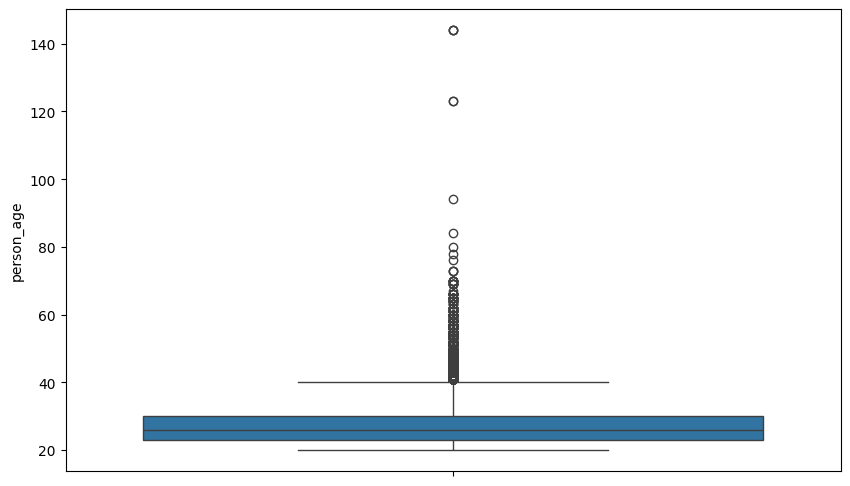

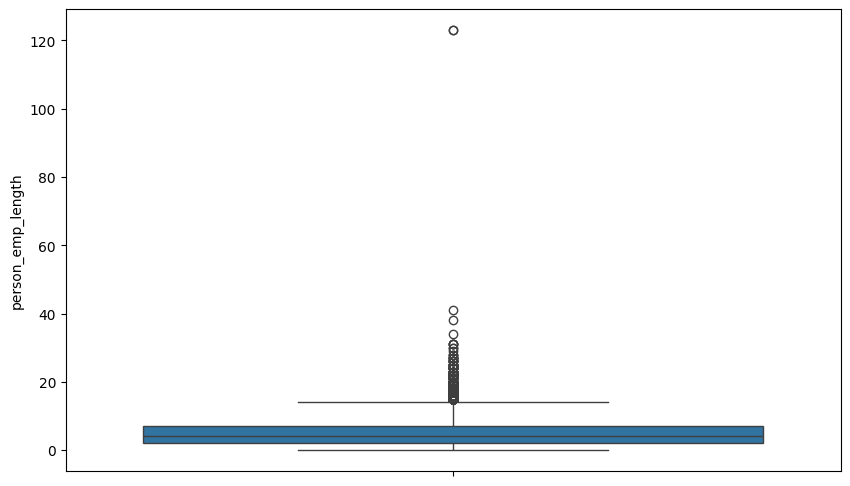

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot( y='person_age', data=df)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot( y='person_emp_length', data=df)
plt.show()


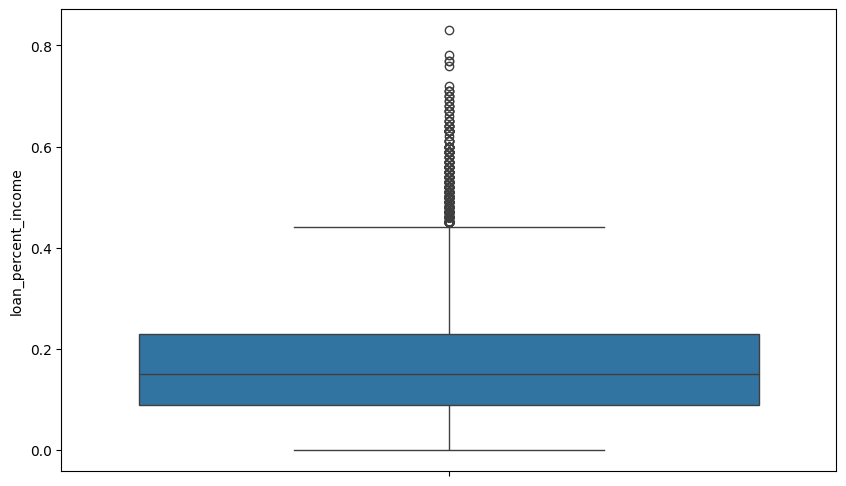

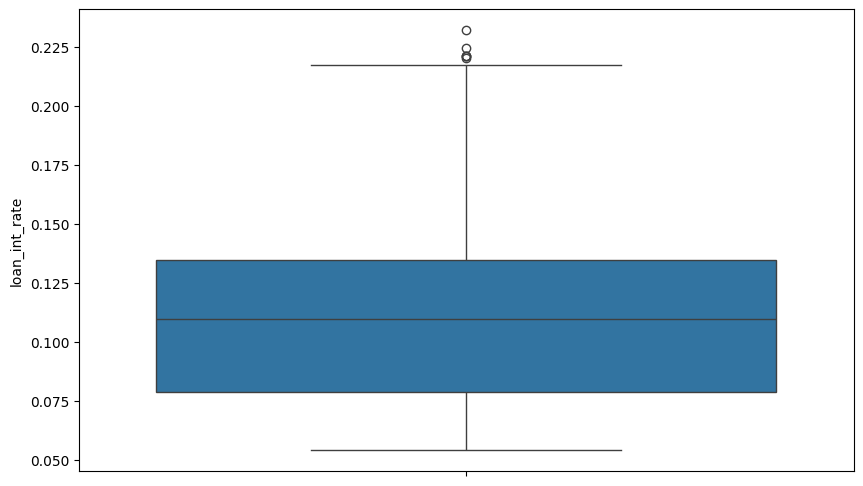

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot( y='loan_percent_income', data=df)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot( y='loan_int_rate', data=df)
plt.show()

In [14]:
df = df[(df['person_age'] >= 18) & (df['person_age'] <= 80)]

df = df[(df['person_emp_length'] >= 0) & (df['person_emp_length'] <= 40) & (df['person_emp_length'] <= df['person_age'] - 16)]

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31671 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31671 non-null  int64  
 1   person_income               31671 non-null  int64  
 2   person_home_ownership       31671 non-null  object 
 3   person_emp_length           31671 non-null  float64
 4   loan_intent                 31671 non-null  object 
 5   loan_grade                  31671 non-null  object 
 6   loan_amnt                   31671 non-null  int64  
 7   loan_int_rate               31671 non-null  float64
 8   loan_status                 31671 non-null  int64  
 9   loan_percent_income         31671 non-null  float64
 10  cb_person_default_on_file   31671 non-null  object 
 11  cb_person_cred_hist_length  31671 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.1+ MB


### Categorical Feature Encoding

.

In [16]:
# Identify categorical columns
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,False,False,True,False,False,False,False,False,False,False


### Feature Scaling


In [17]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
numerical_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,-1.092709,-1.065582,0.086322,-1.355767,0.037262,0,-0.656393,-0.944161,False,True,...,False,False,False,True,False,False,False,False,False,False
2,-0.449204,-1.065582,-0.937026,-0.644230,0.574790,1,3.744111,-0.698676,False,False,...,True,False,False,False,True,False,False,False,False,False
3,-0.770957,-0.006651,-0.169515,4.020295,1.308065,1,3.369600,-0.944161,False,False,...,True,False,False,False,True,False,False,False,False,False
4,-0.610081,-0.216922,0.853833,4.020295,1.009783,1,3.556855,-0.453191,False,False,...,True,False,False,False,True,False,False,False,False,True
5,-1.092709,-1.059899,-0.681189,-1.118588,-1.205578,1,0.748023,-0.944161,False,True,...,False,False,True,False,False,False,False,False,False,False


### Dimensionality Reduction

In [20]:
from sklearn.decomposition import PCA
#dimentionality reduction
X = df.drop('loan_status', axis=1)
y = df['loan_status']

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, index=X.index)

print("Explained variance ratio of each component:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))
print("Original number of features:", X.shape[1])
print("Number of components after PCA:", X_pca.shape[1])

df_pca['loan_status'] = y

df_pca.head()

Explained variance ratio of each component: [0.23332462 0.18863351 0.14352344 0.12102143 0.0992534  0.03148647
 0.02712746 0.02205126 0.02179865 0.0203934  0.01981093 0.01686448
 0.01428653]
Total explained variance: 0.9595755890739881
Original number of features: 22
Number of components after PCA: 13


,0,1,2,3,4,5,6,7,8,9,10,11,12,loan_status
1,-1.728215,-1.258091,-0.312773,-0.045634,0.854351,0.537882,-0.869909,0.584497,-0.568703,0.482179,0.011130,0.133843,-0.103153,0
2,-1.567827,2.312637,-1.945223,-0.710226,0.089168,-0.678636,0.463014,-1.144369,-1.436038,1.497182,0.348721,0.413940,0.221846,1
3,-0.779396,5.424083,0.505062,-0.232916,-0.219352,-0.310517,0.531038,-0.163211,0.915722,0.360974,-0.168894,0.593612,-0.035629,1
4,-0.150134,5.477579,0.515937,-0.645080,0.650338,-0.646083,0.721074,-0.136536,0.903001,0.327798,-0.183010,0.632383,-0.196327,1
5,-1.975492,-0.558320,-0.634289,-1.346783,-0.149976,-0.548071,-0.490574,-0.727704,-0.932912,-0.032601,-0.461750,-0.183052,-0.139825,1
